In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("/content/train.csv")
sample = pd.read_csv("/content/sample_submission.csv")

In [10]:
train['date'] = pd.to_datetime(train['date'], errors='coerce')
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['week'] = train['date'].dt.isocalendar().week
train['day'] = train['date'].dt.day
train['quarter'] = train['date'].dt.quarter
train['day_of_week'] = train['date'].dt.dayofweek
train['is_weekend'] = train['day_of_week'].isin([5, 6]).astype(int)

In [11]:
train.head(4)

,date,store,item,sales,year,month,week,day,quarter,day_of_week,is_weekend
0,2013-01-01,1.0,1.0,13.0,2013.0,1.0,1,1.0,1.0,1.0,0
1,2013-01-02,1.0,1.0,11.0,2013.0,1.0,1,2.0,1.0,2.0,0
2,2013-01-03,1.0,1.0,14.0,2013.0,1.0,1,3.0,1.0,3.0,0
3,2013-01-04,1.0,1.0,13.0,2013.0,1.0,1,4.0,1.0,4.0,0


In [12]:
sale_df = train.groupby('item')['sales'].sum()

**2. Feature Engineering**

In [22]:
train

,date,store,item,sales,year,month,week,day,quarter,day_of_week,is_weekend
0,2013-01-01,1.0,1.0,13.0,2013.0,1.0,1,1.0,1.0,1.0,0
1,2013-01-02,1.0,1.0,11.0,2013.0,1.0,1,2.0,1.0,2.0,0
2,2013-01-03,1.0,1.0,14.0,2013.0,1.0,1,3.0,1.0,3.0,0
3,2013-01-04,1.0,1.0,13.0,2013.0,1.0,1,4.0,1.0,4.0,0
4,2013-01-05,1.0,1.0,10.0,2013.0,1.0,1,5.0,1.0,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...
282044,2015-04-21,5.0,16.0,15.0,2015.0,4.0,17,21.0,2.0,1.0,0
282045,2015-04-22,5.0,16.0,14.0,2015.0,4.0,17,22.0,2.0,2.0,0
282046,2015-04-23,5.0,16.0,16.0,2015.0,4.0,17,23.0,2.0,3.0,0
282047,2015-04-24,5.0,16.0,25.0,2015.0,4.0,17,24.0,2.0,4.0,0


In [23]:
train = train.sort_values(['store', 'item', 'date']).reset_index(drop=True)

In [24]:
group = train.groupby(['store','item'])['sales']
train['lag_1'] = group.shift(1)
train['lag_7'] = group.shift(7)
train['lag_14'] = group.shift(14)
train['lag_28'] = group.shift(28)

In [25]:

train['rolling_mean_7'] = (train.groupby(['store','item'])['sales'].
                           shift(1).rolling(7).mean())
train['rolling_mean_28'] = (train.groupby(['store','item'])['sales'].
                            shift(1).rolling(28).mean())

In [26]:
daily_sales = daily_sales.sort_values('date')

daily_sales['rolling_7'] = (
    daily_sales['sales'].rolling(7).mean()
)

daily_sales['rolling_30'] = (
    daily_sales['sales'].rolling(30).mean())

In [27]:
train = train.dropna().reset_index(drop=True)

In [28]:
train_data = train[train['date'] < '2017-01-01']
valid_data = train[train['date'] >= '2017-01-01']

In [29]:
valid_data.sample(4)

,date,store,item,sales,year,month,week,day,quarter,day_of_week,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28
263200,2017-08-30,10.0,7.0,79.0,2017.0,8.0,35,30.0,3.0,2.0,0,73.0,81.0,89.0,72.0,81.285714,84.535714
46722,2017-12-06,2.0,10.0,67.0,2017.0,12.0,49,6.0,4.0,2.0,0,82.0,73.0,89.0,117.0,89.000000,105.464286
167793,2017-05-09,6.0,14.0,59.0,2017.0,5.0,19,9.0,2.0,1.0,0,44.0,53.0,50.0,54.0,57.142857,53.928571
5081,2017-02-22,1.0,3.0,25.0,2017.0,2.0,8,22.0,1.0,2.0,0,29.0,22.0,20.0,25.0,30.000000,27.250000


**2. Baseline**

In [30]:
valid_data['pred_baseline'] = valid_data['lag_7']

/tmp/ipykernel_617/2719664835.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_data['pred_baseline'] = valid_data['lag_7']


In [31]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(valid_data['sales'],valid_data['pred_baseline']) ** 0.5
mae = mean_absolute_error(valid_data['sales'],valid_data['pred_baseline'])
print(f"MSE: {mse}")
print(f"MAE: {mae}")

MSE: 12.027939217873362
MAE: 9.153478028820494


In [32]:
features = ['store','item','year','month','week','day','day_of_week','quarter','is_weekend',
            'lag_1','lag_7','lag_14','lag_28','rolling_mean_7','rolling_mean_28'
          ]

In [33]:
x_train = train_data[features]
x_valid = valid_data[features]
y_train = train_data['sales']
y_valid = valid_data['sales']

In [34]:
print(train.shape)
print(train.memory_usage(deep=True).sum() / 1024**2)

(277708, 17)
35.2242431640625


In [35]:
categorical_features = ['store', 'item']

numerical_features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'year',
    'month',
    'week',
    'day',
    'quarter',
    'day_of_week',
    'is_weekend'
]

In [36]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [37]:
X_train_cat = encoder.fit_transform(
    train_data[categorical_features]
)

In [38]:
X_valid_cat = encoder.transform(
    valid_data[categorical_features]
)

In [39]:
import numpy as np

X_train_num = train_data[numerical_features].values
X_valid_num = valid_data[numerical_features].values

X_train_final = np.hstack([
    X_train_num,
    X_train_cat
])

X_valid_final = np.hstack([
    X_valid_num,
    X_valid_cat
])

In [40]:
from xgboost import XGBRegressor

xgb_ohe = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb_ohe.fit(
    X_train_final,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [41]:
y_valid_pred = xgb_ohe.predict(X_valid_final)

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_valid, y_valid_pred)

rmse = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred)
)

r2 = r2_score(y_valid, y_valid_pred)

mask = y_valid != 0

mape = np.mean(
    np.abs(
        (y_valid[mask] - y_valid_pred[mask])
        / y_valid[mask]
    )
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)
print("MAPE:", mape)

MAE : 6.303748888071057
RMSE: 8.212581798926516
R²  : 0.9373686260101384
MAPE: 0.12287740631992622


**5. XGBOOST**

In [43]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=500,learning_rate=0.05,max_depth=7,random_state=42)
xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
xgb_pred = xgb.predict(x_valid)
xgb_mse = mean_squared_error(y_valid,xgb_pred) ** 0.5
xgb_mae = mean_absolute_error(y_valid,xgb_pred)
print(f"MSE: {xgb_mse}")
print(f"MAE: {xgb_mae}")

MSE: 8.242997505503212
MAE: 6.318627576135779


**6. LigthXBoosting**

In [45]:
from lightgbm import LGBMRegressor
lgb = LGBMRegressor(n_estimators=500,learning_rate=0.05,random_state=42)
lgb.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011090 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1407
[LightGBM] [Info] Number of data points in the train set: 221498, number of used features: 15
[LightGBM] [Info] Start training from score 54.251095


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [46]:
lgb_pred = lgb.predict(x_valid)
lgb_mse = mean_squared_error(y_valid,lgb_pred) ** 0.5
lgb_mae = mean_absolute_error(y_valid,lgb_pred)
print(f"MSE: {lgb_mse}")
print(f"MAE: {lgb_mae}")

MSE: 8.231940304037062
MAE: 6.3204725053481425


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score,mean_absolute_percentage_error

models = {
    'XGBoost': xgb,
    'LightGBM': lgb
}

for name, model in models.items():

    # Training prediction
    train_pred = model.predict(x_train)

    # Validation prediction
    valid_pred = model.predict(x_valid)

    # Training metrics
    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
    train_r2_sc = r2_score(y_train,train_pred)
    train_mape = mean_absolute_percentage_error(y_train,train_pred) * 100

    # Validation metrics
    valid_mae = mean_absolute_error(y_valid, valid_pred)
    valid_rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
    valid_r2_sc = r2_score(y_valid,valid_pred)
    valid_mape = mean_absolute_percentage_error(y_valid,valid_pred) * 100

    # Print metrics

    print(f"\n{name}")
    print(f"Train MAE : {train_mae:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Train R2: {train_r2_sc:.4f}")
    print(f"Train MAPE: {train_mape:.4f}")
    print(f"Valid MAE : {valid_mae:.4f}")
    print(f"Valid RMSE: {valid_rmse:.4f}")
    print(f"Valid R2: {valid_r2_sc:.4f}")
    print(f"Valid MAPE: {valid_mape:.2f}")


XGBoost
Train MAE : 5.4689
Train RMSE: 7.0552
Train R2: 0.9409
Train MAPE: 21741041538387.4375
Valid MAE : 6.3186
Valid RMSE: 8.2430
Valid R2: 0.9369
Valid MAPE: 12.31

LightGBM
Train MAE : 5.7198
Train RMSE: 7.4055
Train R2: 0.9349
Train MAPE: 22283117929435.5273
Valid MAE : 6.3205
Valid RMSE: 8.2319
Valid R2: 0.9371
Valid MAPE: 12.34


**Hyper Parameter Tunning**

In [48]:
from sklearn.model_selection import TimeSeriesSplit,RandomizedSearchCV
from xgboost import XGBRegressor
tscv = TimeSeriesSplit(n_splits=3)

In [49]:
xgb = XGBRegressor(objective = 'reg:squarederror',random_state=42,n_jobs=2)

In [50]:
params_grid = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}


In [51]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params_grid,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=1
)

**Final Test**

In [53]:

test = pd.read_csv('test.csv')

train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

test = test.sort_values(['date', 'store', 'item']).reset_index(drop=True)

history = train[['date', 'store', 'item', 'sales']].copy()

history = history.sort_values(
    ['store', 'item', 'date']
).reset_index(drop=True)

In [54]:
print(test.shape)
print(test['date'].nunique())

(45000, 4)
90


In [55]:
predictions = []

xgb.fit(x_train, y_train) # Fit the model before making predictions

for current_date in sorted(test['date'].unique()):

    print("Predicting:", current_date)

    # Today's 500 test rows
    today = test[test['date'] == current_date].copy()

    # --------------------------------
    # Create lag features
    # --------------------------------

    for lag in [1, 7, 14, 28]:

        lookup = history[['date', 'store', 'item', 'sales']].copy()

        # Move historical date forward
        # so it matches today's date

        lookup['date'] = ( lookup['date'] + pd.Timedelta(days=lag))

        lookup = lookup.rename(
            columns={
                'sales': f'lag_{lag}'
            }
        )

        today = today.merge(
            lookup[
                ['date', 'store', 'item', f'lag_{lag}']
            ],
            on=['date', 'store', 'item'],
            how='left'
        )

    # --------------------------------
    # Rolling mean 7
    # --------------------------------

    rolling_7 = (
        history
        .groupby(['store', 'item'])['sales']
        .rolling(7)
        .mean()
        .groupby(level=[0, 1])
        .last()
        .reset_index()
    )

    rolling_7 = rolling_7.rename(
        columns={'sales': 'rolling_mean_7'}
    )

    today = today.merge(
        rolling_7,
        on=['store', 'item'],
        how='left'
    )

    # --------------------------------
    # Rolling mean 28
    # --------------------------------

    rolling_28 = (
        history
        .groupby(['store', 'item'])['sales']
        .rolling(28)
        .mean()
        .groupby(level=[0, 1])
        .last()
        .reset_index()
    )

    rolling_28 = rolling_28.rename(
        columns={'sales': 'rolling_mean_28'}
    )

    today = today.merge(
        rolling_28,
        on=['store', 'item'],
        how='left'
    )

    # --------------------------------
    # Date features
    # --------------------------------

    today['year'] = today['date'].dt.year
    today['month'] = today['date'].dt.month
    today['week'] = today['date'].dt.isocalendar().week.astype(int)
    today['day'] = today['date'].dt.day
    today['quarter'] = today['date'].dt.quarter
    today['day_of_week'] = today['date'].dt.dayofweek

    today['is_weekend'] = (
        today['day_of_week'].isin([5, 6])
    ).astype(int)

    # --------------------------------
    # Select XGBoost features
    # --------------------------------

    X_today = today[features]
    print(X_today)
    # --------------------------------
    # Predict today's sales
    # --------------------------------

    today['sales'] = xgb.predict(X_today)

    # --------------------------------
    # Save today's predictions
    # --------------------------------

    predictions.append(today)

    # --------------------------------
    # Add predictions to history
    # --------------------------------

    history = pd.concat(
        [
            history,
            today[
                ['date', 'store', 'item', 'sales']
            ]
        ],
        ignore_index=True
    )

Predicting: 2018-01-01 00:00:00
     store  item  year  month  week  day  day_of_week  quarter  is_weekend  \
0        1     1  2018      1     1    1            0        1           0   
1        1     2  2018      1     1    1            0        1           0   
2        1     3  2018      1     1    1            0        1           0   
3        1     4  2018      1     1    1            0        1           0   
4        1     5  2018      1     1    1            0        1           0   
..     ...   ...   ...    ...   ...  ...          ...      ...         ...   
495     10    46  2018      1     1    1            0        1           0   
496     10    47  2018      1     1    1            0        1           0   
497     10    48  2018      1     1    1            0        1           0   
498     10    49  2018      1     1    1            0        1           0   
499     10    50  2018      1     1    1            0        1           0   

     lag_1  lag_7  lag_14  lag_

In [56]:
predictions_df = pd.concat(predictions,ignore_index=True)

In [57]:
print(predictions_df.head())
print(predictions_df.shape)
print(predictions_df['sales'].describe())
print(predictions_df.isna().sum())

     id       date  store  item  lag_1  lag_7  lag_14  lag_28  rolling_mean_7  \
0     0 2018-01-01      1     1   23.0   13.0    19.0     7.0       18.142857   
1   900 2018-01-01      1     2   67.0   37.0    37.0    33.0       51.142857   
2  1800 2018-01-01      1     3   29.0   26.0    21.0    21.0       26.428571   
3  2700 2018-01-01      1     4   15.0   11.0    11.0    10.0       17.285714   
4  3600 2018-01-01      1     5   17.0   12.0    10.0    13.0       14.142857   

   rolling_mean_28  year  month  week  day  quarter  day_of_week  is_weekend  \
0        16.678571  2018      1     1    1        1            0           0   
1        46.285714  2018      1     1    1        1            0           0   
2        27.785714  2018      1     1    1        1            0           0   
3        15.821429  2018      1     1    1        1            0           0   
4        13.785714  2018      1     1    1        1            0           0   

       sales  
0  12.736925  
1 

In [58]:
predictions_df.head()

,id,date,store,item,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,year,month,week,day,quarter,day_of_week,is_weekend,sales
0,0,2018-01-01,1,1,23.0,13.0,19.0,7.0,18.142857,16.678571,2018,1,1,1,1,0,0,12.736925
1,900,2018-01-01,1,2,67.0,37.0,37.0,33.0,51.142857,46.285714,2018,1,1,1,1,0,0,36.237755
2,1800,2018-01-01,1,3,29.0,26.0,21.0,21.0,26.428571,27.785714,2018,1,1,1,1,0,0,20.199389
3,2700,2018-01-01,1,4,15.0,11.0,11.0,10.0,17.285714,15.821429,2018,1,1,1,1,0,0,12.423331
4,3600,2018-01-01,1,5,17.0,12.0,10.0,13.0,14.142857,13.785714,2018,1,1,1,1,0,0,10.573585


**SHAP**

In [59]:
import shap
import matplotlib.pyplot as plt

In [60]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(x_valid)

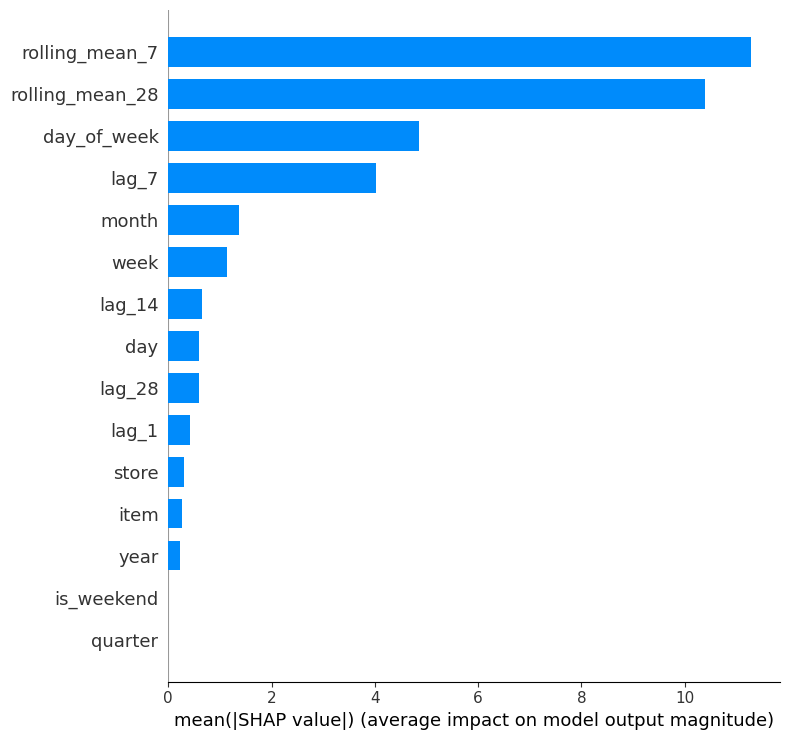

In [61]:
shap.summary_plot(
    shap_values,
    x_valid,
    plot_type="bar"
)

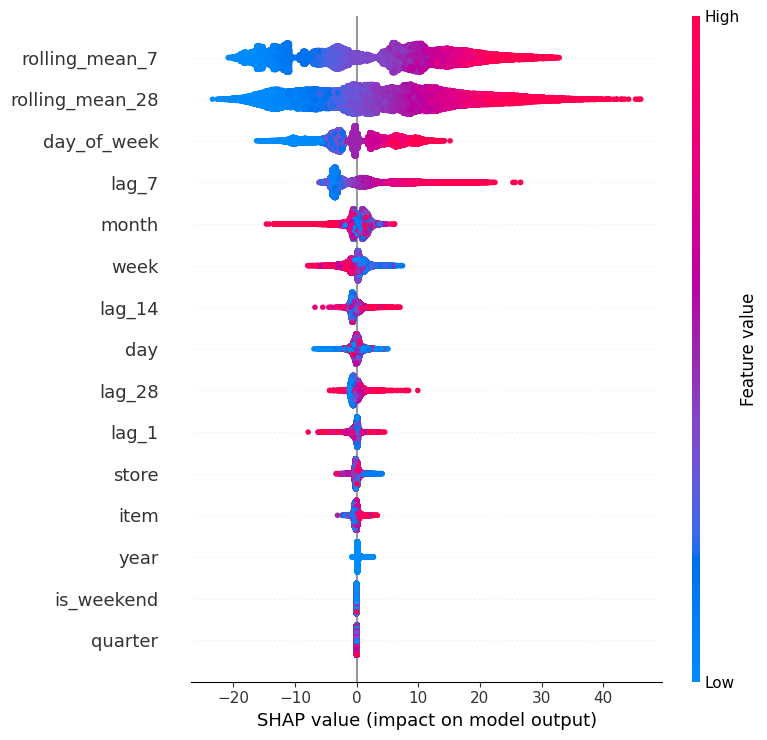

In [62]:
shap.summary_plot(
    shap_values,
    x_valid
)

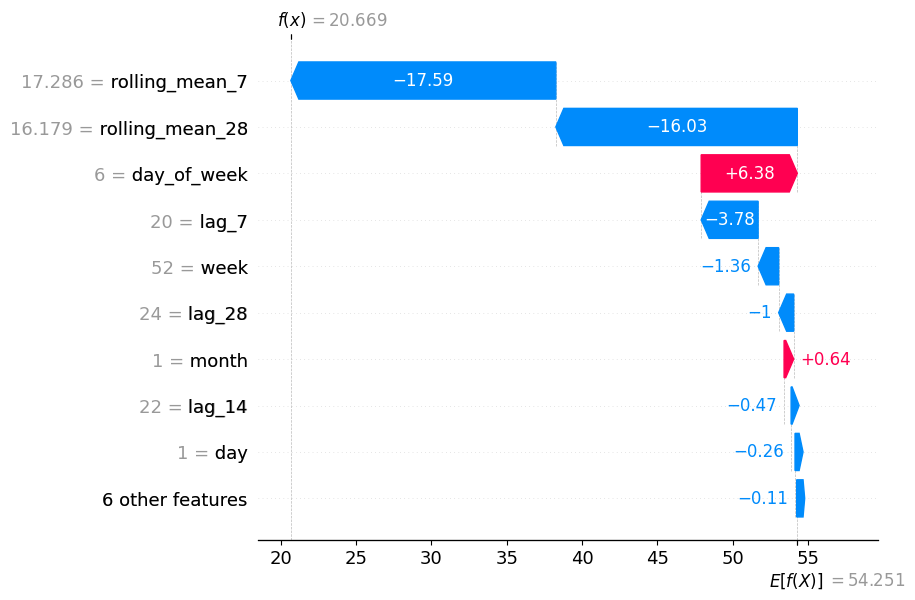

In [66]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=x_valid.iloc[0],
        feature_names=x_valid.columns
    )
)

In [63]:
explainer_ohe = shap.TreeExplainer(xgb_ohe)

shap_values_ohe = explainer_ohe.shap_values(X_valid_final)

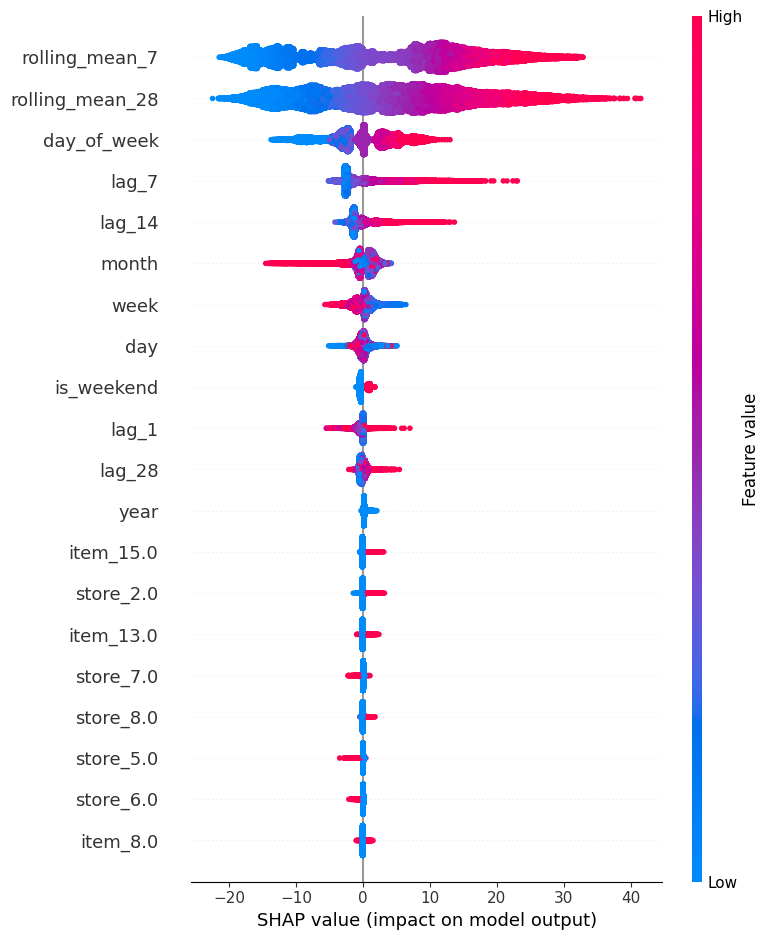

In [64]:
feature_names = numerical_features + list(encoder.get_feature_names_out(categorical_features))
shap.summary_plot(
    shap_values_ohe,
    X_valid_final,
    feature_names=feature_names
)

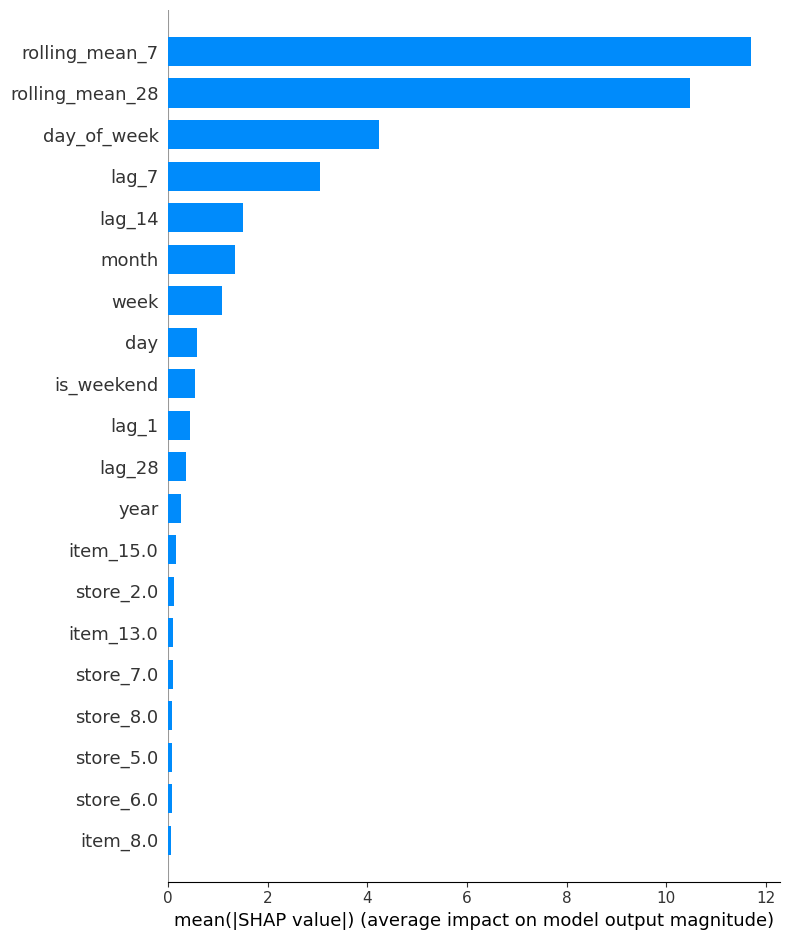

In [65]:
shap.summary_plot(
    shap_values_ohe,
    X_valid_final,
    feature_names=feature_names,
    plot_type="bar"
)

**Inventory Optimization**

In [67]:
print(train[['date', 'store', 'item', 'sales']].head())
print(train[['date', 'store', 'item', 'sales']].shape)

print(predictions_df.head())
print(predictions_df.shape)

        date  store  item  sales
0 2013-01-29    1.0   1.0    6.0
1 2013-01-30    1.0   1.0    9.0
2 2013-01-31    1.0   1.0   13.0
3 2013-02-01    1.0   1.0   11.0
4 2013-02-02    1.0   1.0   21.0
(277708, 4)
     id       date  store  item  lag_1  lag_7  lag_14  lag_28  rolling_mean_7  \
0     0 2018-01-01      1     1   23.0   13.0    19.0     7.0       18.142857   
1   900 2018-01-01      1     2   67.0   37.0    37.0    33.0       51.142857   
2  1800 2018-01-01      1     3   29.0   26.0    21.0    21.0       26.428571   
3  2700 2018-01-01      1     4   15.0   11.0    11.0    10.0       17.285714   
4  3600 2018-01-01      1     5   17.0   12.0    10.0    13.0       14.142857   

   rolling_mean_28  year  month  week  day  quarter  day_of_week  is_weekend  \
0        16.678571  2018      1     1    1        1            0           0   
1        46.285714  2018      1     1    1        1            0           0   
2        27.785714  2018      1     1    1        1            

In [68]:

# ============================================================
# INVENTORY OPTIMIZATION PARAMETERS
# ============================================================

LEAD_TIME = 7
SERVICE_LEVEL = 0.95

# Z-value for 95% service level
Z = 1.645


# ============================================================
# 1. ORIGINAL HISTORICAL SALES
# ============================================================
# IMPORTANT:
# history must contain ACTUAL historical sales.
# Do not use future XGBoost predictions here.

historical_sales = history[ ['date', 'store', 'item', 'sales']].copy()

historical_sales['date'] = pd.to_datetime(historical_sales['date'])

print("Historical data shape:")
print(historical_sales.shape)

print("\nHistorical store-item combinations:")
print(historical_sales[['store', 'item']].drop_duplicates().shape)


# ============================================================
# 2. HISTORICAL DEMAND STATISTICS
# ============================================================

demand_stats = (historical_sales.groupby(['store', 'item'])['sales'].agg(
        historical_mean='mean',
        demand_std='std')
    .reset_index()
)

# ============================================================
# 3. SAFETY STOCK
# ============================================================

demand_stats['safety_stock'] = (Z * demand_stats['demand_std'] * np.sqrt(LEAD_TIME))

# ============================================================
# 4. CREATE INVENTORY DATA FROM PREDICTIONS
# ============================================================

inventory_df = predictions_df[['id', 'date', 'store', 'item', 'sales']].copy()

inventory_df['date'] = pd.to_datetime(inventory_df['date'])

# Rename predicted sales
inventory_df = inventory_df.rename(columns={'sales': 'predicted_demand'})

# ============================================================
# 5. MERGE HISTORICAL STATISTICS
# ============================================================

inventory_df = inventory_df.merge(demand_stats,on=['store', 'item'],how='left')

# ============================================================
# 6. CHECK FOR MISSING HISTORICAL STATISTICS
# ============================================================

missing_stats = inventory_df[ inventory_df['historical_mean'].isna() | inventory_df['demand_std'].isna() ]

if len(missing_stats) > 0:

    print("\nWARNING:",len(missing_stats),"rows have missing historical statistics.")

    print(missing_stats[['store', 'item']].drop_duplicates().head(20))

else:

    print(
        "\nAll store-item combinations have "
        "historical statistics."
    )


# ============================================================
# 7. SORT DATA
# ============================================================

inventory_df = inventory_df.sort_values(['store', 'item', 'date']).reset_index(drop=True)


# ============================================================
# 8. FORWARD 7-DAY LEAD-TIME DEMAND
# ============================================================
#
# Example:
#
# Jan 1:
# Jan 2 + Jan 3 + Jan 4 + Jan 5 + Jan 6 + Jan 7 + Jan 8
#
# Jan 2:
# Jan 3 + Jan 4 + Jan 5 + Jan 6 + Jan 7 + Jan 8 + Jan 9
#
# ============================================================

def calculate_forward_demand(x):

    return (x.shift(-1).iloc[::-1].rolling( window=LEAD_TIME, min_periods=LEAD_TIME)
         .sum()
         .iloc[::-1]
    )


inventory_df['lead_time_demand'] = (inventory_df.groupby(['store', 'item'])['predicted_demand']
                                    .transform(calculate_forward_demand ) )


# ============================================================
# 9. HANDLE FINAL FORECAST DATES
# ============================================================
#
# The last 6 dates don't have enough future predictions
# to calculate a complete 7-day forecast.
#
# Therefore use:
#
# historical_mean × lead_time
#
# as the fallback.
# ============================================================

inventory_df['lead_time_demand'] = (
    inventory_df['lead_time_demand']
    .fillna(
        inventory_df['historical_mean']
        * LEAD_TIME
    )
)


# ============================================================
# 10. SAFETY STOCK
# ============================================================

# Already calculated at store-item level,
# but we keep this explicitly here.

inventory_df['safety_stock'] = (
    inventory_df['safety_stock']
)


# ============================================================
# 11. REORDER POINT
# ============================================================
#
# Reorder Point =
#
# Expected demand during lead time
# +
# Safety stock
#
# ============================================================

inventory_df['reorder_point'] = (
    inventory_df['lead_time_demand']
    + inventory_df['safety_stock']
)


# ============================================================
# 12. ROUND VALUES
# ============================================================

inventory_df['predicted_demand'] = (
    inventory_df['predicted_demand']
    .round(2)
)

inventory_df['historical_mean'] = (
    inventory_df['historical_mean']
    .round(2)
)

inventory_df['demand_std'] = (
    inventory_df['demand_std']
    .round(2)
)

inventory_df['lead_time_demand'] = (
    inventory_df['lead_time_demand']
    .round(2)
)

inventory_df['safety_stock'] = (
    inventory_df['safety_stock']
    .round(2)
)

inventory_df['reorder_point'] = (
    inventory_df['reorder_point']
    .round(2)
)


# ============================================================
# 13. FINAL COLUMN ORDER
# ============================================================

inventory_df = inventory_df[
    [
        'id',
        'date',
        'store',
        'item',
        'predicted_demand',
        'historical_mean',
        'demand_std',
        'lead_time_demand',
        'safety_stock',
        'reorder_point'
    ]
]


# ============================================================
# 14. FINAL CHECK
# ============================================================

print("\n" + "=" * 60)
print("INVENTORY OPTIMIZATION RESULTS")
print("=" * 60)

print("\nFirst 20 rows:")
print(inventory_df.head(20))

print("\nShape:")
print(inventory_df.shape)

print("\nMissing values:")
print(inventory_df.isna().sum())

print("\nNumber of store-item combinations:")
print(
    inventory_df[['store', 'item']]
    .drop_duplicates()
    .shape[0]
)

print("\nDate range:")
print(
    inventory_df['date'].min(),
    "to",
    inventory_df['date'].max()
)

Historical data shape:
(322708, 4)

Historical store-item combinations:
(500, 2)

All store-item combinations have historical statistics.

INVENTORY OPTIMIZATION RESULTS

First 20 rows:
    id       date  store  item  predicted_demand  historical_mean  demand_std  \
0    0 2018-01-01      1     1         12.740000            20.04        6.56   
1    1 2018-01-02      1     1         15.480000            20.04        6.56   
2    2 2018-01-03      1     1         15.770000            20.04        6.56   
3    3 2018-01-04      1     1         16.799999            20.04        6.56   
4    4 2018-01-05      1     1         17.639999            20.04        6.56   
5    5 2018-01-06      1     1         18.580000            20.04        6.56   
6    6 2018-01-07      1     1         19.860001            20.04        6.56   
7    7 2018-01-08      1     1         13.630000            20.04        6.56   
8    8 2018-01-09      1     1         15.320000            20.04        6.56   
9   

In [69]:
print(
    demand_stats[
        (demand_stats['store'] == 10) &
        (demand_stats['item'] == 50)
    ]
)

     store  item  historical_mean  demand_std  safety_stock
499   10.0  50.0       129.722678   18.688759     81.338354


In [70]:
train[
    (train['store'] == 10) &
    (train['item'] == 50)
].shape

(0, 17)

In [71]:
print("Train combinations:",
      train[['store', 'item']].drop_duplicates().shape)

print("Test combinations:",
      test[['store', 'item']].drop_duplicates().shape)

Train combinations: (155, 2)
Test combinations: (500, 2)


In [72]:
# ============================================================
# 15. CURRENT INVENTORY
# ============================================================
#
# IMPORTANT:
# Your dataset does not contain actual inventory levels.
#
# For this project we simulate current inventory as:
#
# Current Inventory =
# Historical Average Daily Demand × Lead Time
#
# Example:
# historical_mean = 20
# lead_time = 7
#
# current_inventory = 20 × 7 = 140 units
#
# Replace this with real inventory data when available.
# ============================================================

inventory_df['current_inventory'] = (
    inventory_df['historical_mean']
    * LEAD_TIME
)


# ============================================================
# 16. INVENTORY POSITION
# ============================================================
#
# Inventory Position represents how much inventory
# is currently available relative to the reorder point.
#
# Here we use current inventory because we don't have
# outstanding purchase orders in the dataset.
# ============================================================

inventory_df['inventory_position'] = (
    inventory_df['current_inventory']
)


# ============================================================
# 17. RECOMMENDED ORDER QUANTITY
# ============================================================
#
# Recommended Order =
#
# Reorder Point - Current Inventory
#
# If current inventory is already above the reorder point,
# order quantity = 0.
#
# ============================================================

inventory_df['recommended_order_qty'] = (inventory_df['reorder_point']
                                         - inventory_df['inventory_position']
                                        ).clip(lower=0)


# ============================================================
# 18. ROUND INVENTORY VALUES
# ============================================================

inventory_df['current_inventory'] = (
    inventory_df['current_inventory']
    .round(2)
)

inventory_df['inventory_position'] = (
    inventory_df['inventory_position']
    .round(2)
)

inventory_df['recommended_order_qty'] = (
    inventory_df['recommended_order_qty']
    .round(0)
    .astype(int)
)


# ============================================================
# 19. FINAL INVENTORY OPTIMIZATION TABLE
# ============================================================

inventory_df = inventory_df[
    [
        'id',
        'date',
        'store',
        'item',
        'predicted_demand',
        'historical_mean',
        'demand_std',
        'lead_time_demand',
        'safety_stock',
        'reorder_point',
        'current_inventory',
        'inventory_position',
        'recommended_order_qty'
    ]
]


# ============================================================
# 20. DISPLAY RESULTS
# ============================================================

print("=" * 70)
print("FINAL INVENTORY OPTIMIZATION TABLE")
print("=" * 70)

print(inventory_df.head(20))

print("\nShape:")
print(inventory_df.shape)

print("\nMissing values:")
print(inventory_df.isna().sum())


# ============================================================
# 21. EXAMPLE STORE / ITEM
# ============================================================

print("\n" + "=" * 70)
print("EXAMPLE: STORE 1, ITEM 1")
print("=" * 70)

print(
    inventory_df[(inventory_df['store'] == 1) & (inventory_df['item'] == 1)].head(10)
)

FINAL INVENTORY OPTIMIZATION TABLE
    id       date  store  item  predicted_demand  historical_mean  demand_std  \
0    0 2018-01-01      1     1         12.740000            20.04        6.56   
1    1 2018-01-02      1     1         15.480000            20.04        6.56   
2    2 2018-01-03      1     1         15.770000            20.04        6.56   
3    3 2018-01-04      1     1         16.799999            20.04        6.56   
4    4 2018-01-05      1     1         17.639999            20.04        6.56   
5    5 2018-01-06      1     1         18.580000            20.04        6.56   
6    6 2018-01-07      1     1         19.860001            20.04        6.56   
7    7 2018-01-08      1     1         13.630000            20.04        6.56   
8    8 2018-01-09      1     1         15.320000            20.04        6.56   
9    9 2018-01-10      1     1         15.320000            20.04        6.56   
10  10 2018-01-11      1     1         15.790000            20.04        6

In [74]:
inventory_df

,id,date,store,item,predicted_demand,historical_mean,demand_std,lead_time_demand,safety_stock,reorder_point,current_inventory,inventory_position,recommended_order_qty
0,0,2018-01-01,1,1,12.740000,20.04,6.56,117.76,28.57,146.33,140.28,140.28,6
1,1,2018-01-02,1,1,15.480000,20.04,6.56,117.59,28.57,146.16,140.28,140.28,6
2,2,2018-01-03,1,1,15.770000,20.04,6.56,117.14,28.57,145.71,140.28,140.28,5
3,3,2018-01-04,1,1,16.799999,20.04,6.56,116.13,28.57,144.70,140.28,140.28,4
4,4,2018-01-05,1,1,17.639999,20.04,6.56,115.70,28.57,144.27,140.28,140.28,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,44995,2018-03-27,10,50,116.209999,129.72,18.69,908.06,81.34,989.40,908.04,908.04,81
44996,44996,2018-03-28,10,50,117.099998,129.72,18.69,908.06,81.34,989.40,908.04,908.04,81
44997,44997,2018-03-29,10,50,125.410004,129.72,18.69,908.06,81.34,989.40,908.04,908.04,81
44998,44998,2018-03-30,10,50,129.000000,129.72,18.69,908.06,81.34,989.40,908.04,908.04,81


In [73]:
inventory_df.to_csv('inventory_forecast.csv', index=False)

In [76]:
print(train['date'].min())
print(train['date'].max())

2013-01-29 00:00:00
2017-12-31 00:00:00


In [75]:
inventory_df['calculated_initial_inventory'] = (
    inventory_df['historical_mean'] * 7
)



In [77]:
inventory_df[ ['store', 'item', 'historical_mean', 'calculated_initial_inventory'] ].head(10)

,store,item,historical_mean,calculated_initial_inventory
0,1,1,20.04,140.28
1,1,1,20.04,140.28
2,1,1,20.04,140.28
3,1,1,20.04,140.28
4,1,1,20.04,140.28
5,1,1,20.04,140.28
6,1,1,20.04,140.28
7,1,1,20.04,140.28
8,1,1,20.04,140.28
9,1,1,20.04,140.28


In [79]:
inventory_df

,id,date,store,item,predicted_demand,historical_mean,demand_std,lead_time_demand,safety_stock,reorder_point,current_inventory,inventory_position,recommended_order_qty,calculated_initial_inventory
0,0,2018-01-01,1,1,12.740000,20.04,6.56,117.76,28.57,146.33,140.28,140.28,6,140.28
1,1,2018-01-02,1,1,15.480000,20.04,6.56,117.59,28.57,146.16,140.28,140.28,6,140.28
2,2,2018-01-03,1,1,15.770000,20.04,6.56,117.14,28.57,145.71,140.28,140.28,5,140.28
3,3,2018-01-04,1,1,16.799999,20.04,6.56,116.13,28.57,144.70,140.28,140.28,4,140.28
4,4,2018-01-05,1,1,17.639999,20.04,6.56,115.70,28.57,144.27,140.28,140.28,4,140.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,44995,2018-03-27,10,50,116.209999,129.72,18.69,908.06,81.34,989.40,908.04,908.04,81,908.04
44996,44996,2018-03-28,10,50,117.099998,129.72,18.69,908.06,81.34,989.40,908.04,908.04,81,908.04
44997,44997,2018-03-29,10,50,125.410004,129.72,18.69,908.06,81.34,989.40,908.04,908.04,81,908.04
44998,44998,2018-03-30,10,50,129.000000,129.72,18.69,908.06,81.34,989.40,908.04,908.04,81,908.04


In [78]:
inventory_df['calculated_initial_inventory'] = (
    inventory_df['historical_mean'] * 7
)

inventory_df[
    ['date', 'store', 'item',
     'historical_mean',
     'calculated_initial_inventory',
     'reorder_point']
].head(10)

,date,store,item,historical_mean,calculated_initial_inventory,reorder_point
0,2018-01-01,1,1,20.04,140.28,146.33
1,2018-01-02,1,1,20.04,140.28,146.16
2,2018-01-03,1,1,20.04,140.28,145.71
3,2018-01-04,1,1,20.04,140.28,144.70
4,2018-01-05,1,1,20.04,140.28,144.27
5,2018-01-06,1,1,20.04,140.28,144.07
6,2018-01-07,1,1,20.04,140.28,143.74
7,2018-01-08,1,1,20.04,140.28,143.62
8,2018-01-09,1,1,20.04,140.28,143.20
9,2018-01-10,1,1,20.04,140.28,142.78


In [80]:
inventory_df.columns.tolist()

['id',
 'date',
 'store',
 'item',
 'predicted_demand',
 'historical_mean',
 'demand_std',
 'lead_time_demand',
 'safety_stock',
 'reorder_point',
 'current_inventory',
 'inventory_position',
 'recommended_order_qty',
 'calculated_initial_inventory']

In [81]:
sim = inventory_df[
    (inventory_df['store'] == 1) &
    (inventory_df['item'] == 1)
].copy()

sim = sim.sort_values('date').reset_index(drop=True)

sim.head(10)

,id,date,store,item,predicted_demand,historical_mean,demand_std,lead_time_demand,safety_stock,reorder_point,current_inventory,inventory_position,recommended_order_qty,calculated_initial_inventory
0,0,2018-01-01,1,1,12.740000,20.04,6.56,117.76,28.57,146.33,140.28,140.28,6,140.28
1,1,2018-01-02,1,1,15.480000,20.04,6.56,117.59,28.57,146.16,140.28,140.28,6,140.28
2,2,2018-01-03,1,1,15.770000,20.04,6.56,117.14,28.57,145.71,140.28,140.28,5,140.28
3,3,2018-01-04,1,1,16.799999,20.04,6.56,116.13,28.57,144.70,140.28,140.28,4,140.28
4,4,2018-01-05,1,1,17.639999,20.04,6.56,115.70,28.57,144.27,140.28,140.28,4,140.28
5,5,2018-01-06,1,1,18.580000,20.04,6.56,115.50,28.57,144.07,140.28,140.28,4,140.28
6,6,2018-01-07,1,1,19.860001,20.04,6.56,115.17,28.57,143.74,140.28,140.28,3,140.28
7,7,2018-01-08,1,1,13.630000,20.04,6.56,115.05,28.57,143.62,140.28,140.28,3,140.28
8,8,2018-01-09,1,1,15.320000,20.04,6.56,114.63,28.57,143.20,140.28,140.28,3,140.28
9,9,2018-01-10,1,1,15.320000,20.04,6.56,114.21,28.57,142.78,140.28,140.28,2,140.28


In [82]:
initial_inventory = sim.loc[0, 'calculated_initial_inventory']
demand = sim.loc[0, 'predicted_demand']
rop = sim.loc[0, 'reorder_point']

inventory_after_demand = initial_inventory - demand

print("Initial Inventory:", initial_inventory)
print("Predicted Demand:", demand)
print("Inventory After Demand:", inventory_after_demand)
print("Reorder Point:", rop)
print("Order Required:", inventory_after_demand < rop)

Initial Inventory: 140.28
Predicted Demand: 12.74
Inventory After Demand: 127.54000022888184
Reorder Point: 146.33
Order Required: True


In [83]:
sim_df = inventory_df.copy()

sim_df = sim_df.sort_values(
    ['store', 'item', 'date']
).reset_index(drop=True)

In [84]:
sim_df['opening_inventory'] = 0.0
sim_df['inventory_after_demand'] = 0.0
sim_df['on_order'] = 0.0
sim_df['inventory_position'] = 0.0
sim_df['order_quantity'] = 0.0
sim_df['arrival_date'] = pd.NaT

In [85]:
for (store, item), group in sim_df.groupby(['store', 'item']):

    inventory = group.iloc[0]['calculated_initial_inventory']

    for idx in group.index:

        # Opening inventory
        sim_df.loc[idx, 'opening_inventory'] = inventory

        # Today's predicted demand
        demand = sim_df.loc[idx, 'predicted_demand']

        # Subtract demand
        inventory = inventory - demand

        # Store closing inventory
        sim_df.loc[idx, 'inventory_after_demand'] = inventory

In [86]:
sim_df[ (sim_df['store'] == 1) & (sim_df['item'] == 1)] [[ 'date', 'predicted_demand', 'opening_inventory', 'inventory_after_demand']].head(10)

,date,predicted_demand,opening_inventory,inventory_after_demand
0,2018-01-01,12.740000,140.280000,127.540000
1,2018-01-02,15.480000,127.540000,112.060001
2,2018-01-03,15.770000,112.060001,96.290000
3,2018-01-04,16.799999,96.290000,79.490001
4,2018-01-05,17.639999,79.490001,61.850002
5,2018-01-06,18.580000,61.850002,43.270002
6,2018-01-07,19.860001,43.270002,23.410001
7,2018-01-08,13.630000,23.410001,9.780001
8,2018-01-09,15.320000,9.780001,-5.539999
9,2018-01-10,15.320000,-5.539999,-20.859998
